In [41]:
import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Data import CodonTable
import os
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def read_gene_expression(file_path):
    """
    Read gene expression data with RNA-Seq RSEM normalized values

    Parameters:
    file_path (str): Path to gene expression file

    Returns:
    pandas.DataFrame: DataFrame with patient_id, sample_id and gene expression values
    """
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Gene expression data loaded: {df.shape[0]} samples, {df.shape[1]-2} genes")
    return df

def read_somatic_mutations(file_path):
    """
    Read somatic mutations data in MAF format

    Parameters:
    file_path (str): Path to mutation annotation file
    2`x
    Returns:
    pandas.DataFrame: DataFrame with mutation information
    """
    # Read the tab-separated MAF file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Somatic mutations data loaded: {df.shape[0]} mutations")
    return df

def read_patient_metadata(file_path):
    """
    Read patient clinical and pathological metadata

    Parameters:
    file_path (str): Path to patient metadata file

    Returns:
    pandas.DataFrame: DataFrame with patient clinical information
    """
    # Read the tab-separated metadata file
    df = pd.read_csv(file_path, sep='\t')
    print(f"Patient metadata loaded: {df.shape[0]} patients")
    return df

def explore_data(gene_expr, somatic_mut, patient_meta):
    """
    Basic exploration of the three datasets
    """
    # Explore patient metadata
    print("\nPatient demographics:")
    print(f"Gender distribution:\n{patient_meta['gender'].value_counts()}")
    print(f"Age statistics:\n{patient_meta['age_at_initial_pathologic_diagnosis'].describe()}")

    # Analyze survival data
    print("\nSurvival statistics:")
    print(f"Overall survival events: {patient_meta['DSS'].sum()} deaths out of {patient_meta['DSS'].count()} patients")

    # Look at mutations per patient
    if 'patient_id' in somatic_mut.columns:
        mutations_per_patient = somatic_mut['patient_id'].value_counts()
        print(f"\nMutations per patient statistics:")
        print(mutations_per_patient.describe())

    # For gene expression, we could look at the most variable genes
    if gene_expr is not None and gene_expr.shape[1] > 2:
        print("\nGene expression statistics:")
        gene_columns = gene_expr.columns[2:]  # Skipping patient_id and sample_id
        gene_variance = gene_expr[gene_columns].var().sort_values(ascending=False)
        print(f"Top 5 most variable genes:\n{gene_variance.head(5)}")

gene_expression_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.expression.txt')
somatic_mutations_path = os.path.join(os.getcwd(), 'Team_4_STAD', 'TCGA.STAD.mutations.txt')
metadata_path = os.path.join(os.getcwd(),'Team_4_STAD', 'TCGA.STAD.metadata.txt')

gene_expr = read_gene_expression(gene_expression_path)
somatic_mut = read_somatic_mutations(somatic_mutations_path)
patient_meta = read_patient_metadata(metadata_path)

Gene expression data loaded: 447 samples, 20531 genes
Somatic mutations data loaded: 234941 mutations
Patient metadata loaded: 415 patients


In [42]:
### ----------------------------------------------------
### 1.  Construct 5-year DSS label
### ----------------------------------------------------
# English comments inside code
# We assume patient_meta has: 'DSS' (1=death,0=alive) and 'DSS_time' (months)

# Create 5-year (60-month) binary outcome
patient_meta['label_5yr'] = (
    (patient_meta['DSS'] == 1) & (patient_meta['DSS.time'] <= 240)
).astype(int)

print("Positive cases (death within 5y):", patient_meta['label_5yr'].sum())
print("Negative cases:", (patient_meta['label_5yr'] == 0).sum())

Positive cases (death within 5y): 20
Negative cases: 395


In [43]:
### ----------------------------------------------------
### 2.  Merge gene expression with clinical labels
### ----------------------------------------------------
# Keep only expression columns and patient_id
from sklearn.preprocessing import FunctionTransformer

expr_only = gene_expr.drop(columns=['sample_id'], errors='ignore')
data = expr_only.merge(
    patient_meta[['patient_id', 'label_5yr']], on='patient_id', how='inner'
)

# Separate features and labels
X = data.drop(columns=['patient_id', 'label_5yr'])
y = data['label_5yr']

# Basic preprocessing: log2(x+1) transform, median imputation, z-score scaling
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocess = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log',      FunctionTransformer(lambda x: np.log2(x + 1), validate=False)),
    ('scale',   StandardScaler())
])

X_processed = preprocess.fit_transform(X)


In [44]:
### ----------------------------------------------------
### 3.  Train-test split (stratified 80/20)
### ----------------------------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)
print("Train set size:", X_train.shape, " Test set size:", X_test.shape)


Train set size: (357, 20531)  Test set size: (90, 20531)


In [45]:
### --- Revised feature-selection pipeline ---
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.linear_model import LogisticRegression

var_filter = VarianceThreshold(threshold=1e-4)
X_var = var_filter.fit_transform(X_train)

log_reg = LogisticRegression(
    penalty='l1', C=2.0, solver='liblinear', class_weight='balanced',
    max_iter=500
)
sfm = SelectFromModel(log_reg, threshold='mean', max_features=150)
sfm.fit(X_var, y_train)

X_train_sel = sfm.transform(X_var)
X_test_sel  = sfm.transform(var_filter.transform(X_test))

print("Selected features:", X_train_sel.shape[1])

Selected features (A): 140


In [46]:
### ----------------------------------------------------
### 5.  Model training: RandomForest + GridSearchCV
### ----------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
print("Train label counts:\n", y_train.value_counts())
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    rf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_sel, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)
best_model = grid.best_estimator_

Train label counts:
 label_5yr
0    341
1     16
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC: 0.9123934356351237


AUC                     0.576
Accuracy                0.956
Precision               0.000
Recall (Sensitivity)    0.000
Specificity             1.000
F1                      0.000
dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


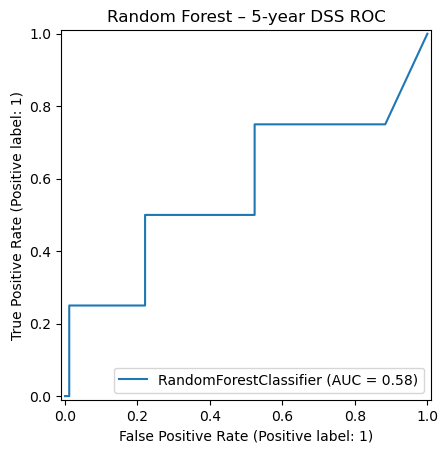

In [47]:
### ----------------------------------------------------
### 6.  Test-set evaluation
### ----------------------------------------------------
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, RocCurveDisplay
)
y_pred = best_model.predict(X_test_sel)
y_prob = best_model.predict_proba(X_test_sel)[:, 1]

metrics = {
    'AUC': roc_auc_score(y_test, y_prob),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall (Sensitivity)': recall_score(y_test, y_pred),
    'Specificity': recall_score(y_test, y_pred, pos_label=0),
    'F1': f1_score(y_test, y_pred)
}
print(pd.Series(metrics).round(3))

# Plot ROC curve
import matplotlib.pyplot as plt
RocCurveDisplay.from_estimator(best_model, X_test_sel, y_test)
plt.title('Random Forest – 5-year DSS ROC')
plt.show()


In [48]:
### ----------------------------------------------------
### 7.  Feature importance & biological interpretation
### ----------------------------------------------------
importances = best_model.feature_importances_
selected_gene_names = X.columns[var_filter.get_support()][sfm.get_support()]

imp_df = (
    pd.DataFrame({'Gene': selected_gene_names, 'Importance': importances})
      .sort_values('Importance', ascending=False)
      .head(20)
)
print(imp_df)

# Save to file if needed
# imp_df.to_csv('top20_genes_importance.csv', index=False)

                Gene  Importance
17    C2orf27A|29798    0.036574
34      CRYGN|155051    0.035907
1            ACO1|48    0.027082
96         RAG1|5896    0.024754
139   ZSCAN5B|342933    0.021113
133       UPK1B|7348    0.020024
89       PHF5A|84844    0.019579
54     H2AFB1|474382    0.019442
36     CT45A5|441521    0.019065
101     SEC61G|23480    0.016761
29       CIB4|130106    0.016340
4          ALOX5|240    0.016228
127    TMEM81|388730    0.015448
136     ZNF48|197407    0.014542
115    SPRED3|399473    0.014464
60       IL31|386653    0.014375
105      SETD4|54093    0.014224
12   C17orf97|400566    0.014028
64    KIAA1239|57495    0.013826
123     SYNGR4|23546    0.013807
